In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df=pd.read_csv('DataCoSupplyChainDataset.csv',encoding='latin1')

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 53 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Type                           180519 non-null  object 
 1   Days for shipping (real)       180519 non-null  int64  
 2   Days for shipment (scheduled)  180519 non-null  int64  
 3   Benefit per order              180519 non-null  float64
 4   Sales per customer             180519 non-null  float64
 5   Delivery Status                180519 non-null  object 
 6   Late_delivery_risk             180519 non-null  int64  
 7   Category Id                    180519 non-null  int64  
 8   Category Name                  180519 non-null  object 
 9   Customer City                  180519 non-null  object 
 10  Customer Country               180519 non-null  object 
 11  Customer Email                 180519 non-null  object 
 12  Customer Fname                

In [4]:
# Data Cleaning
cols_to_drop = [
    'Customer Email',
    'Customer Fname',
    'Customer Lname',
    'Customer Password',
    'Customer Street',
    'Customer Zipcode',
    'Latitude',
    'Longitude',
    'Product Image',
    'Product Description',
    'Order Zipcode',
    'Order Customer Id',
    'Customer Id',
    'Product Card Id',
    'Order Item Cardprod Id',
    'Order Item Id',
    'Category Id',
    'Department Id',
    'Product Category Id',
    'Order Item Discount',
    'Order Item Discount Rate',
    'Order Item Product Price',
    'Order Item Quantity',
    'Order Item Total',
    'Benefit per order',
    'Order City',
    'Order Country',
    'Order State'
    
    
]
# dropping columns that r either fully missing, redundant, or have only one value (and thus no variance)
df = df.drop(columns=cols_to_drop)

In [5]:
df.describe()

,Days for shipping (real),Days for shipment (scheduled),Sales per customer,Late_delivery_risk,Order Id,Order Item Profit Ratio,Sales,Order Profit Per Order,Product Price,Product Status
count,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.0
mean,3.497654,2.931847,183.107609,0.548291,36221.894903,0.120647,203.772096,21.974989,141.232550,0.0
std,1.623722,1.374449,120.043670,0.497664,21045.379569,0.466796,132.273077,104.433526,139.732492,0.0
min,0.000000,0.000000,7.490000,0.000000,1.000000,-2.750000,9.990000,-4274.979980,9.990000,0.0
25%,2.000000,2.000000,104.379997,0.000000,18057.000000,0.080000,119.980003,7.000000,50.000000,0.0
50%,3.000000,4.000000,163.990005,1.000000,36140.000000,0.270000,199.919998,31.520000,59.990002,0.0
75%,5.000000,4.000000,247.399994,1.000000,54144.000000,0.360000,299.950012,64.800003,199.990005,0.0
max,6.000000,4.000000,1939.989990,1.000000,77204.000000,0.500000,1999.989990,911.799988,1999.989990,0.0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 25 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Type                           180519 non-null  object 
 1   Days for shipping (real)       180519 non-null  int64  
 2   Days for shipment (scheduled)  180519 non-null  int64  
 3   Sales per customer             180519 non-null  float64
 4   Delivery Status                180519 non-null  object 
 5   Late_delivery_risk             180519 non-null  int64  
 6   Category Name                  180519 non-null  object 
 7   Customer City                  180519 non-null  object 
 8   Customer Country               180519 non-null  object 
 9   Customer Segment               180519 non-null  object 
 10  Customer State                 180519 non-null  object 
 11  Department Name                180519 non-null  object 
 12  Market                        

In [7]:
df.isnull().sum()

Type                             0
Days for shipping (real)         0
Days for shipment (scheduled)    0
Sales per customer               0
Delivery Status                  0
Late_delivery_risk               0
Category Name                    0
Customer City                    0
Customer Country                 0
Customer Segment                 0
Customer State                   0
Department Name                  0
Market                           0
order date (DateOrders)          0
Order Id                         0
Order Item Profit Ratio          0
Sales                            0
Order Profit Per Order           0
Order Region                     0
Order Status                     0
Product Name                     0
Product Price                    0
Product Status                   0
shipping date (DateOrders)       0
Shipping Mode                    0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
# removing cancelled orders since they r not relevant for delivery time analysis and may have different patterns than completed orders
df = df[df['Delivery Status'] != 'Shipping canceled']

In [10]:
# standard date conversion 
df['order date (DateOrders)'] = pd.to_datetime(df['order date (DateOrders)'])
df['shipping date (DateOrders)'] = pd.to_datetime(df['shipping date (DateOrders)'])

In [11]:
# value counts for categorical columns with low cardinality
for col in df.columns:
    if df[col].nunique() < 10:
        print(f"\n{'='*50}")
        print(f"Column: {col}")
        print(f"Unique Values: {df[col].nunique()}")
        print(df[col].value_counts())


Column: Type
Unique Values: 4
Type
DEBIT       69295
TRANSFER    42129
PAYMENT     41725
CASH        19616
Name: count, dtype: int64

Column: Days for shipping (real)
Unique Values: 7
Days for shipping (real)
2    54205
6    27489
3    27478
4    27297
5    27003
0     4839
1     4454
Name: count, dtype: int64

Column: Days for shipment (scheduled)
Unique Values: 4
Days for shipment (scheduled)
4    103153
2     33806
1     26513
0      9293
Name: count, dtype: int64

Column: Delivery Status
Unique Values: 3
Delivery Status
Late delivery       98977
Advance shipping    41592
Shipping on time    32196
Name: count, dtype: int64

Column: Late_delivery_risk
Unique Values: 2
Late_delivery_risk
1    98977
0    73788
Name: count, dtype: int64

Column: Customer Country
Unique Values: 2
Customer Country
EE. UU.        106425
Puerto Rico     66340
Name: count, dtype: int64

Column: Customer Segment
Unique Values: 3
Customer Segment
Consumer       89420
Corporate      52528
Home Office    30817


In [12]:
# calculating the order processing time and delay
df['order_processing_time'] = (
    df['shipping date (DateOrders)'] -
    df['order date (DateOrders)']
).dt.days

df['delay'] = (
    df['order_processing_time'] -
    df['Days for shipment (scheduled)']
)

df['is_delayed'] = df['delay'] > 0

df['order_month'] = df['order date (DateOrders)'].dt.month

df['order_day'] = df['order date (DateOrders)'].dt.day_name()

df['order_hour'] = df['order date (DateOrders)'].dt.hour

In [13]:
df.describe()

,Days for shipping (real),Days for shipment (scheduled),Sales per customer,Late_delivery_risk,order date (DateOrders),Order Id,Order Item Profit Ratio,Sales,Order Profit Per Order,Product Price,Product Status,shipping date (DateOrders),order_processing_time,delay,order_month,order_hour
count,172765.000000,172765.000000,172765.000000,172765.000000,172765,172765.000000,172765.000000,172765.000000,172765.000000,172765.000000,172765.0,172765,172765.000000,172765.000000,172765.000000,172765.000000
mean,3.498596,2.933100,183.165948,0.572900,2016-06-12 15:25:39.457991936,36215.167210,0.120801,203.828493,22.032360,141.278595,0.0,2016-06-16 03:25:14.452927488,3.472816,0.539716,6.235511,11.482604
min,0.000000,0.000000,7.490000,0.000000,2015-01-01 00:00:00,1.000000,-2.750000,9.990000,-4274.979980,9.990000,0.0,2015-01-03 00:00:00,0.000000,-2.000000,1.000000,0.000000
25%,2.000000,2.000000,104.379997,0.000000,2015-09-21 18:01:00,18069.000000,0.080000,119.980003,7.030000,50.000000,0.0,2015-09-25 08:59:00,2.000000,0.000000,3.000000,5.000000
50%,3.000000,4.000000,163.990005,1.000000,2016-06-11 08:11:00,36126.000000,0.270000,199.919998,31.520000,59.990002,0.0,2016-06-15 03:38:00,3.000000,1.000000,6.000000,11.000000
75%,5.000000,4.000000,247.399994,1.000000,2017-02-28 21:08:00,54111.000000,0.360000,299.950012,64.800003,199.990005,0.0,2017-03-04 08:00:00,5.000000,1.000000,9.000000,17.000000
max,6.000000,4.000000,1939.989990,1.000000,2018-01-31 23:38:00,77204.000000,0.500000,1999.989990,911.799988,1999.989990,0.0,2018-02-06 22:14:00,6.000000,4.000000,12.000000,23.000000
std,1.623446,1.373405,120.141871,0.494659,NaN,21036.193887,0.466610,132.392520,104.355313,139.862956,0.0,NaN,1.670187,1.494150,3.405593,6.927276


In [14]:
# profitability flag based on order profit per order
df['profitability flag']=np.where(df['Order Profit Per Order']>0,'profit', np.where(df['Order Profit Per Order']<0 ,'loss','break_even'))

In [15]:
df['profitability flag'].value_counts()

profitability flag
profit        139354
loss           32295
break_even      1116
Name: count, dtype: int64

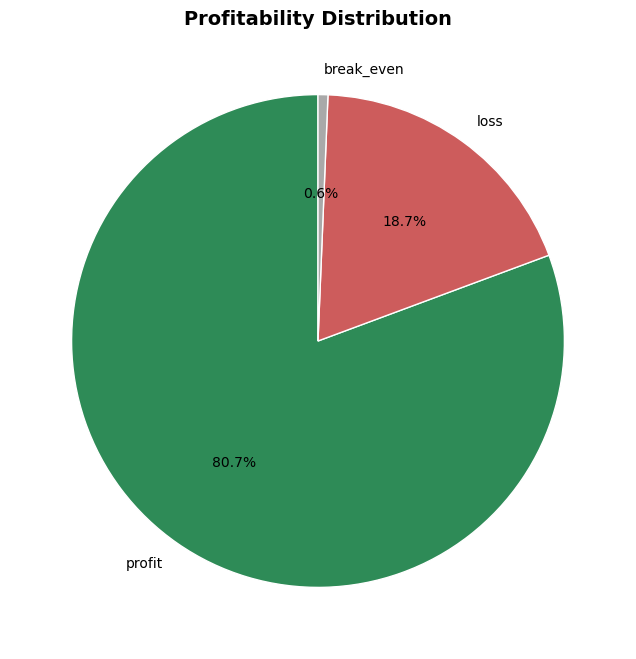

In [16]:
# vishualisation of profitability distribution
profitability_counts = df['profitability flag'].value_counts()

colors = ['#2E8B57', '#CD5C5C', '#A9A9A9']  # Green, Red, Gray

plt.figure(figsize=(8,8))

plt.pie(
    profitability_counts,
    labels=profitability_counts.index,
    autopct='%1.1f%%',
    colors=colors,
    startangle=90,
    wedgeprops={'edgecolor': 'white'}
)

plt.title(
    'Profitability Distribution',
    fontsize=14,
    fontweight='bold'
)

plt.show()

In [17]:
# Business KPIs
def format_func(value):
    if value >= 1e6:
        return f'{value/1e6:.1f}M $'
    elif value >= 1e3:
        return f'{value/1e3:.1f}K $'
    else:
        return f'{value:.0f} $'

delayed_df = df[df['delay'] > 0]
metrics = {}
metrics['Total Orders'] = len(df)
metrics['Late Deliveries'] = len(delayed_df)
metrics['90% Delay (days)'] = delayed_df['delay'].quantile(0.90)
metrics['On time Delivery %'] = (
    1 - (metrics['Late Deliveries'] / metrics['Total Orders'])
) * 100
metrics['Late Delivery %'] = (
    metrics['Late Deliveries'] /
    metrics['Total Orders']
) * 100
metrics['Total Profit'] = format_func(
    df.loc[
        df['Order Profit Per Order'] > 0,
        'Order Profit Per Order'
    ].sum()
)
metrics['Total Loss due to delays'] = format_func(
    abs(
        df.loc[
            (df['delay'] > 0) &
            (df['Order Profit Per Order'] < 0),
            'Order Profit Per Order'
        ].sum()
    )
)
print("\n--- Business KPIs ---\n")
for k, v in metrics.items():
    if isinstance(v, float):
        print(f"{k}: {v:.2f}")
    else:
        print(f"{k}:{v}")


--- Business KPIs ---

Total Orders:172765
Late Deliveries:94523
90% Delay (days): 3.00
On time Delivery %: 45.29
Late Delivery %: 54.71
Total Profit:7.5M $
Total Loss due to delays:2.1M $


In [18]:
# Profitability vs Delivery time analysis
profit_metrics = (
    df.groupby('delay')
      .agg(
          mean_profit=('Order Profit Per Order', 'mean'),
          total_profit=('Order Profit Per Order', 'sum'),
          order_count=('Order Id', 'count')
      )
      .reset_index()
)

In [19]:
profit_metrics.head()

,delay,mean_profit,total_profit,order_count
0,-2,23.360134,4.875961e+05,20873
1,-1,21.604769,4.476292e+05,20719
2,0,22.249118,8.154302e+05,36650
3,1,22.333227,1.194895e+06,53503
4,2,21.128491,5.821110e+05,27551


In [24]:
delay_distribution = (
    df['delay']
    .value_counts(normalize=True)
    .sort_index() * 100
)

print(delay_distribution)

delay
-2    12.081730
-1    11.992591
 0    21.213788
 1    30.968657
 2    15.947096
 3     3.919775
 4     3.876364
Name: proportion, dtype: float64


In [26]:
delay_distribution = (
    df['delay']
    .value_counts(normalize=True)
    .mul(100)
    .sort_index()
    .reset_index()
)

delay_distribution.columns = [
    'delay',
    'percentage_orders'
]

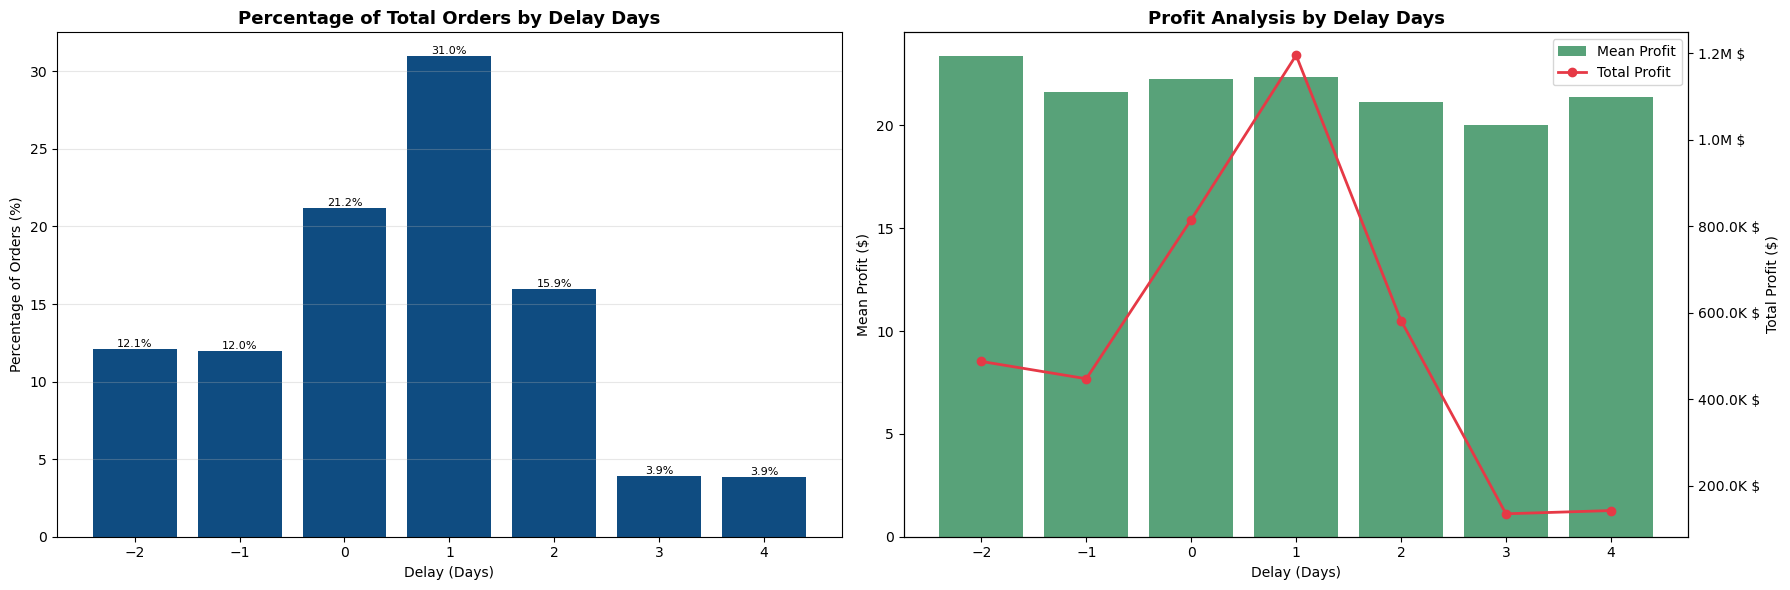

In [27]:
# Vishualisation 

import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter






def currency_formatter(x, pos):
    if abs(x) >= 1_000_000:
        return f'{x/1_000_000:.1f}M $'
    elif abs(x) >= 1_000:
        return f'{x/1_000:.1f}K $'
    return f'{x:.0f} $'



fig, axes = plt.subplots(1, 2, figsize=(18, 6))



bars = axes[0].bar(
    delay_distribution['delay'],
    delay_distribution['percentage_orders'],
    color='#0F4C81'
)


for bar in bars:
    height = bar.get_height()

    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{height:.1f}%',
        ha='center',
        va='bottom',
        fontsize=8
    )

axes[0].set_title(
    'Percentage of Total Orders by Delay Days',
    fontsize=13,
    fontweight='bold'
)

axes[0].set_xlabel('Delay (Days)')
axes[0].set_ylabel('Percentage of Orders (%)')
axes[0].grid(axis='y', alpha=0.3)




ax1 = axes[1]


ax1.bar(
    profit_metrics['delay'],
    profit_metrics['mean_profit'],
    color='#2E8B57',
    alpha=0.8,
    label='Mean Profit'
)

ax1.set_xlabel('Delay (Days)')
ax1.set_ylabel('Mean Profit ($)')


ax2 = ax1.twinx()

ax2.plot(
    profit_metrics['delay'],
    profit_metrics['total_profit'],
    color='#E63946',
    marker='o',
    linewidth=2,
    label='Total Profit'
)

ax2.set_ylabel('Total Profit ($)')
ax2.yaxis.set_major_formatter(
    FuncFormatter(currency_formatter)
)

axes[1].set_title(
    'Profit Analysis by Delay Days',
    fontsize=13,
    fontweight='bold'
)


handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    handles1 + handles2,
    labels1 + labels2,
    loc='upper right'
)



plt.tight_layout()
plt.show()

In [ ]:
delay_by_region = df.groupby('Order Region')['is_delayed'].mean().mul(100).sort_values()
delay_by_segment = df.groupby('Customer Segment')['is_delayed'].mean().mul(100).sort_values()
delay_by_shipping = df.groupby('Shipping Mode')['is_delayed'].mean().mul(100).sort_values()
delay_by_status = df.groupby('Order Status')['is_delayed'].mean().mul(100).sort_values()
delay_by_type = df.groupby('Type')['is_delayed'].mean().mul(100).sort_values()
delay_by_department = df.groupby('Department Name')['is_delayed'].mean().mul(100).sort_values()

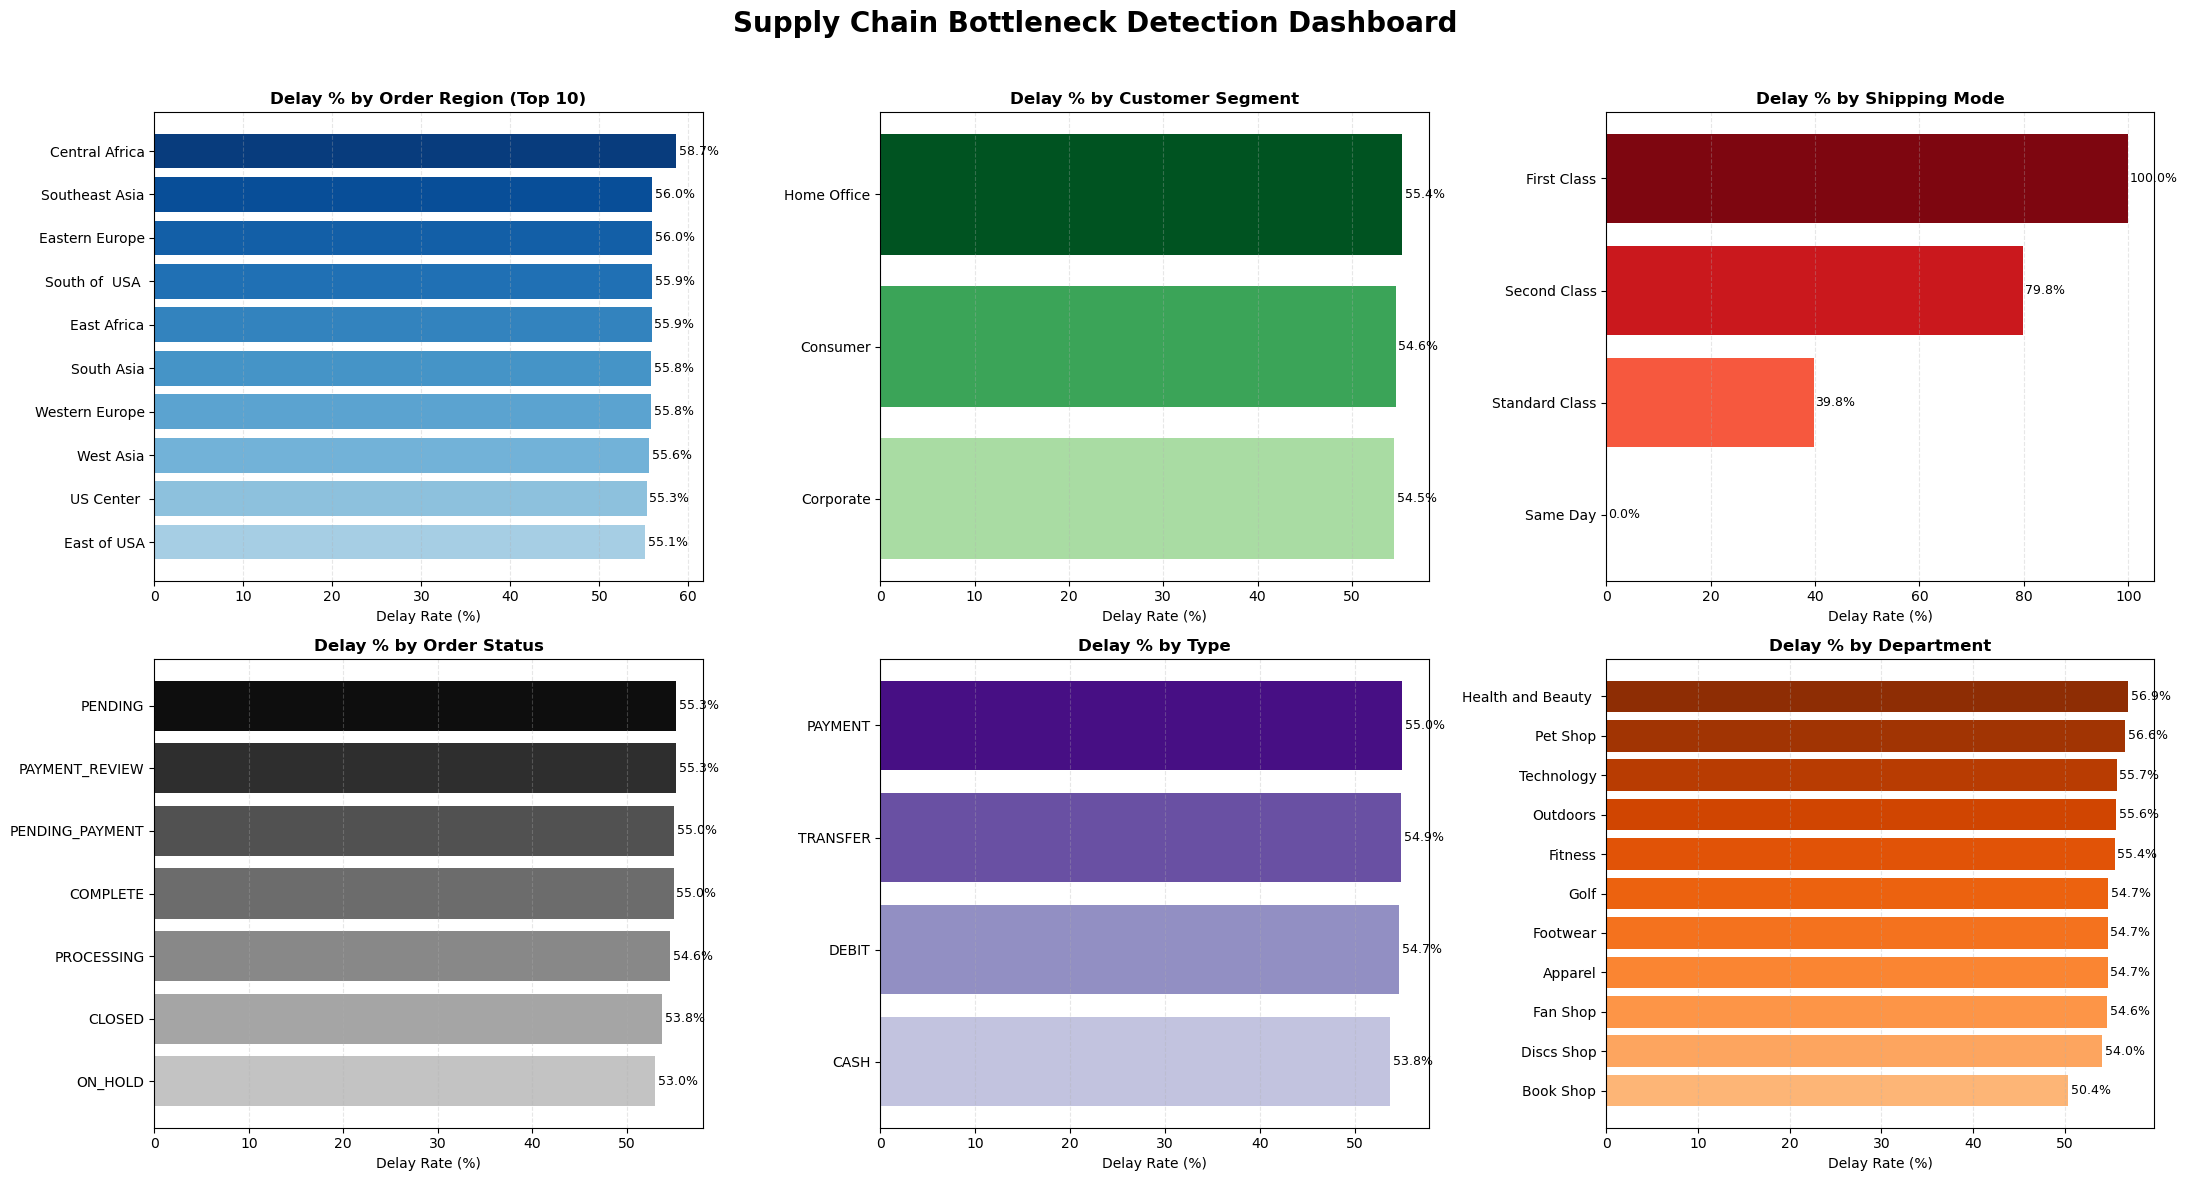

In [28]:
# Bottleneck detection
import matplotlib.cm as cm




delay_by_region = (
    df.groupby('Order Region')['is_delayed']
      .mean()
      .mul(100)
      .sort_values(ascending=False)
      .head(10)
      .sort_values()
)

delay_by_segment = (
    df.groupby('Customer Segment')['is_delayed']
      .mean()
      .mul(100)
      .sort_values()
)

delay_by_shipping = (
    df.groupby('Shipping Mode')['is_delayed']
      .mean()
      .mul(100)
      .sort_values()
)

delay_by_status = (
    df.groupby('Order Status')['is_delayed']
      .mean()
      .mul(100)
      .sort_values()
)

delay_by_type = (
    df.groupby('Type')['is_delayed']
      .mean()
      .mul(100)
      .sort_values()
)

delay_by_department = (
    df.groupby('Department Name')['is_delayed']
      .mean()
      .mul(100)
      .sort_values()
)



fig, axes = plt.subplots(2, 3, figsize=(22, 12))


cmap_list = [
    cm.Blues,
    cm.Greens,
    cm.Reds,
    cm.Greys,
    cm.Purples,
    cm.Oranges
]

datasets = [
    (delay_by_region, 'Delay % by Order Region (Top 10)'),
    (delay_by_segment, 'Delay % by Customer Segment'),
    (delay_by_shipping, 'Delay % by Shipping Mode'),
    (delay_by_status, 'Delay % by Order Status'),
    (delay_by_type, 'Delay % by Type'),
    (delay_by_department, 'Delay % by Department')
]



for ax, (data, title), cmap in zip(
    axes.flatten(),
    datasets,
    cmap_list
):

    colors = cmap(
        np.linspace(0.35, 0.95, len(data))
    )

    bars = ax.barh(
        data.index,
        data.values,
        color=colors
    )

    # Labels
    for bar in bars:
        width = bar.get_width()

        ax.text(
            width + 0.3,
            bar.get_y() + bar.get_height()/2,
            f'{width:.1f}%',
            va='center',
            fontsize=9
        )

    ax.set_title(
        title,
        fontsize=12,
        fontweight='bold'
    )

    ax.set_xlabel('Delay Rate (%)')

    ax.grid(
        axis='x',
        linestyle='--',
        alpha=0.3
    )



plt.suptitle(
    'Supply Chain Bottleneck Detection Dashboard',
    fontsize=20,
    fontweight='bold'
)

plt.tight_layout(rect=[0, 0, 1, 0.96])

plt.show()

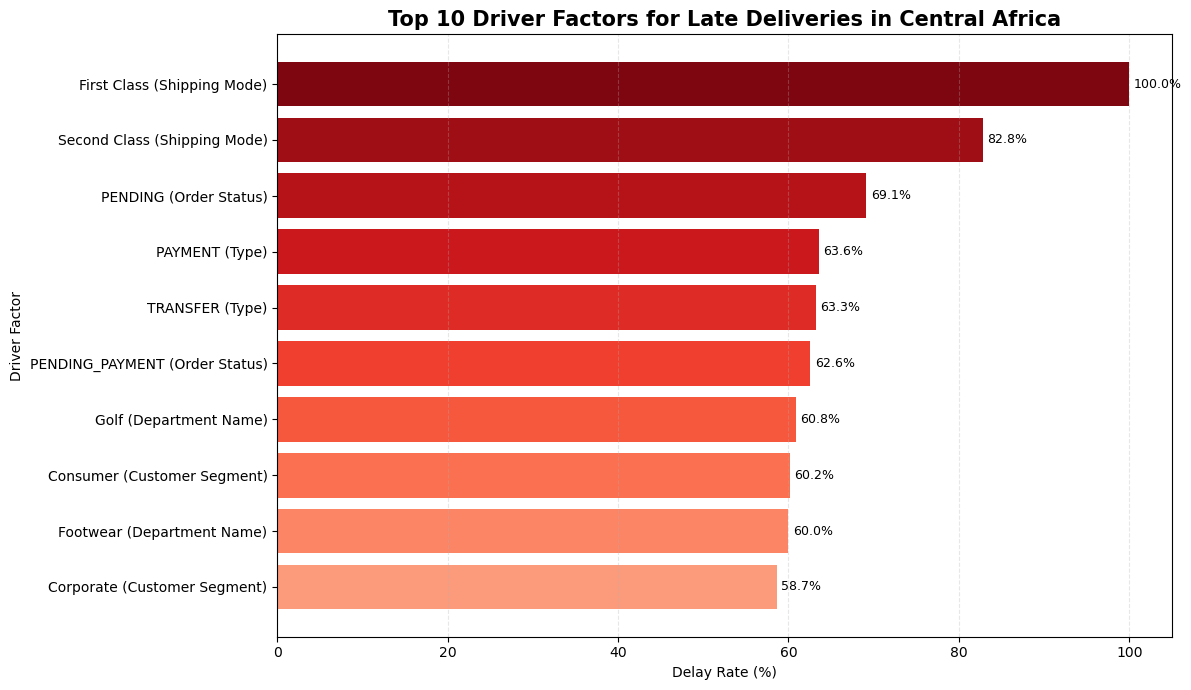

,driver_column,factor,delay_rate,order_count
4,Customer Segment,Corporate,58.679245,530
8,Department Name,Footwear,60.000000,130
3,Customer Segment,Consumer,60.150376,798
9,Department Name,Golf,60.830861,337
17,Order Status,PENDING_PAYMENT,62.576687,326
13,Type,TRANSFER,63.260341,411
12,Type,PAYMENT,63.583815,346
16,Order Status,PENDING,69.148936,188
1,Shipping Mode,Second Class,82.817869,291
0,Shipping Mode,First Class,100.000000,278


In [30]:
# Root cause analysis
# top driver of late delivery by region


central_africa = df[df['Order Region'] == 'Central Africa']


driver_columns = [
    'Shipping Mode',
    'Customer Segment',
    'Department Name',
    'Type',
    'Order Status'
]

driver_results = []

for col in driver_columns:

    temp = (
        central_africa
        .groupby(col)
        .agg(
            delay_rate=('is_delayed', 'mean'),
            order_count=('Order Id', 'count')
        )
        .reset_index()
    )

    
    temp = temp[temp['order_count'] >= 100]

    temp['delay_rate'] = temp['delay_rate'] * 100

    temp['driver_column'] = col

    temp = temp.rename(columns={col: 'factor'})

    driver_results.append(
        temp[['driver_column',
              'factor',
              'delay_rate',
              'order_count']]
    )


driver_analysis = pd.concat(
    driver_results,
    ignore_index=True
)


top_drivers = (
    driver_analysis
    .sort_values('delay_rate', ascending=False)
    .head(10)
    .sort_values('delay_rate')
)


top_drivers['label'] = (
    top_drivers['factor'].astype(str)
    + ' (' +
    top_drivers['driver_column'] +
    ')'
)

# Professional gradient colors
colors = cm.Reds(
    np.linspace(0.35, 0.95, len(top_drivers))
)

# Plot
plt.figure(figsize=(12, 7))

bars = plt.barh(
    top_drivers['label'],
    top_drivers['delay_rate'],
    color=colors
)

# Percentage labels
for bar in bars:
    width = bar.get_width()

    plt.text(
        width + 0.5,
        bar.get_y() + bar.get_height()/2,
        f'{width:.1f}%',
        va='center',
        fontsize=9
    )

plt.title(
    'Top 10 Driver Factors for Late Deliveries in Central Africa',
    fontsize=15,
    fontweight='bold'
)

plt.xlabel('Delay Rate (%)')
plt.ylabel('Driver Factor')

plt.grid(
    axis='x',
    linestyle='--',
    alpha=0.3
)

plt.tight_layout()
plt.show()

# Display underlying data
top_drivers[
    ['driver_column',
     'factor',
     'delay_rate',
     'order_count']
]

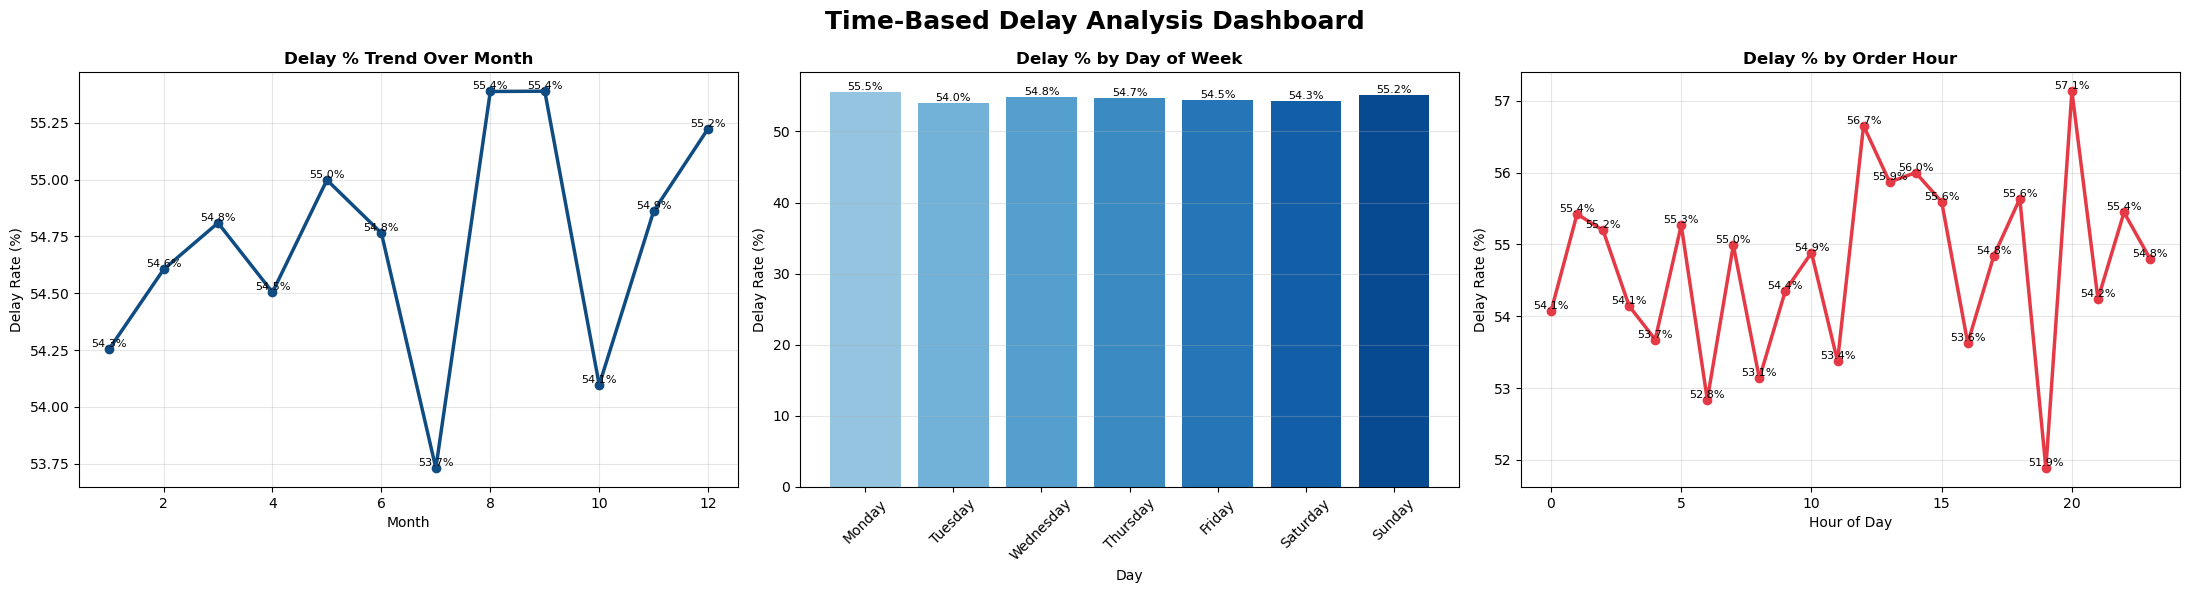

In [44]:
# Time-Based Analysis
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

# =====================================
# Delay % Trend Over Month
# =====================================

delay_by_month = (
    df.groupby('order_month')['is_delayed']
      .mean()
      .mul(100)
      .reset_index()
)

# =====================================
# Delay % by Day of Week
# =====================================

day_order = [
    'Monday', 'Tuesday', 'Wednesday',
    'Thursday', 'Friday', 'Saturday', 'Sunday'
]

delay_by_day = (
    df.groupby('order_day')['is_delayed']
      .mean()
      .mul(100)
      .reindex(day_order)
      .reset_index()
)

# =====================================
# Delay % by Hour
# =====================================

delay_by_hour = (
    df.groupby('order_hour')['is_delayed']
      .mean()
      .mul(100)
      .reset_index()
)



fig, axes = plt.subplots(1, 3, figsize=(22, 6))

# -------------------------------------
# 1. Delay % Trend Over Month
# -------------------------------------

axes[0].plot(
    delay_by_month['order_month'],
    delay_by_month['is_delayed'],
    marker='o',
    linewidth=2.5,
    color='#0F4C81'
)

axes[0].set_title(
    'Delay % Trend Over Month',
    fontweight='bold'
)

axes[0].set_xlabel('Month')
axes[0].set_ylabel('Delay Rate (%)')
axes[0].grid(alpha=0.3)

# Labels
for x, y in zip(
    delay_by_month['order_month'],
    delay_by_month['is_delayed']
):
    axes[0].text(
        x,
        y,
        f'{y:.1f}%',
        ha='center',
        va='bottom',
        fontsize=8
    )

# -------------------------------------
# 2. Delay % by Day of Week
# -------------------------------------

colors = cm.Blues(
    np.linspace(0.4, 0.9, len(delay_by_day))
)

bars = axes[1].bar(
    delay_by_day['order_day'],
    delay_by_day['is_delayed'],
    color=colors
)

axes[1].set_title(
    'Delay % by Day of Week',
    fontweight='bold'
)

axes[1].set_xlabel('Day')
axes[1].set_ylabel('Delay Rate (%)')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', alpha=0.3)

for bar in bars:
    height = bar.get_height()

    axes[1].text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{height:.1f}%',
        ha='center',
        va='bottom',
        fontsize=8
    )

# -------------------------------------
# 3. Delay % by Hour
# -------------------------------------

axes[2].plot(
    delay_by_hour['order_hour'],
    delay_by_hour['is_delayed'],
    marker='o',
    linewidth=2.5,
    color='#E63946'
)

axes[2].set_title(
    'Delay % by Order Hour',
    fontweight='bold'
)

axes[2].set_xlabel('Hour of Day')
axes[2].set_ylabel('Delay Rate (%)')
axes[2].grid(alpha=0.3)

for x, y in zip(
    delay_by_hour['order_hour'],
    delay_by_hour['is_delayed']
):
    axes[2].text(
        x,
        y,
        f'{y:.1f}%',
        ha='center',
        va='bottom',
        fontsize=8
    )

# -------------------------------------
# Layout
# -------------------------------------

plt.suptitle(
    'Time-Based Delay Analysis Dashboard',
    fontsize=18,
    fontweight='bold'
)

plt.tight_layout()
plt.savefig('chart_name.png', dpi=300, bbox_inches='tight')
plt.show()


In [31]:
# Machine Leaning Modeling
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

In [32]:
X = df[[
    'Type',
    'Days for shipment (scheduled)',
    'Category Name',
    'Customer Segment',
    'Department Name',
    'Order Region',
    'Shipping Mode',
    'order_month',
    'order_hour'
]]

y = df['Late_delivery_risk']

In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [34]:
categorical_features = [
    'Type',
    'Category Name',
    'Customer Segment',
    'Department Name',
    'Order Region',
    'Shipping Mode'
]

numerical_features = [
    'Days for shipment (scheduled)',
    'order_month',
    'order_hour'
]

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ],
    remainder='passthrough'
)

In [35]:
model = RandomForestClassifier(
    n_estimators=50,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

In [36]:
clf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', model)
])

In [37]:
import time

start = time.time()

clf.fit(X_train, y_train)

print("Training completed in",
      round(time.time() - start, 2),
      "seconds")

Training completed in 5.35 seconds


In [38]:
# Predictions
y_pred = clf.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# Detailed Metrics
print(classification_report(y_test, y_pred))

Accuracy: 0.7245391138251382
              precision    recall  f1-score   support

           0       0.62      0.91      0.74     14758
           1       0.89      0.59      0.71     19795

    accuracy                           0.72     34553
   macro avg       0.76      0.75      0.72     34553
weighted avg       0.78      0.72      0.72     34553

